In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from src.models.knn import KNN
from src.models.neural_network import NeuralNetwork
from src.evaluation.metrics import accuracy, precision, recall, f1_score, confusion_matrix

In [2]:
data_path = Path("../data/processed/dry_bean_processed.npz")

data = np.load(data_path, allow_pickle=True)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

classes = data["classes"]
features = data["features"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Classes:", classes)

X_train: (10836, 16)
X_test : (2707, 16)
y_train: (10836,)
y_test : (2707,)
Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [3]:
print("Classes:")
for i, cls in enumerate(classes):
    print(i, cls)

print("\nTrain distribution:")
print(np.bincount(y_train))

print("\nTest distribution:")
print(np.bincount(y_test))

Classes:
0 BARBUNYA
1 BOMBAY
2 CALI
3 DERMASON
4 HOROZ
5 SEKER
6 SIRA

Train distribution:
[1058  418 1304 2837 1488 1622 2109]

Test distribution:
[264 104 326 709 372 405 527]


In [4]:
results = {}
predictions = {}
confusion_matrices = {}

In [5]:
knn = KNN(k=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [6]:
print("KNN accuracy:", knn.score(X_test, y_test))

KNN accuracy: 0.9250092353158478


In [7]:
results["KNN"] = {
    "Accuracy": accuracy(y_test, y_pred_knn),
    "Precision": precision(y_test, y_pred_knn),
    "Recall": recall(y_test, y_pred_knn),
    "F1": f1_score(y_test, y_pred_knn),
}

predictions["KNN"] = y_pred_knn
confusion_matrices["KNN"] = confusion_matrix(y_test, y_pred_knn)

results["KNN"]

{'Accuracy': np.float64(0.9250092353158478),
 'Precision': np.float64(0.9388762114591757),
 'Recall': np.float64(0.935405903845702),
 'F1': np.float64(0.9370907819621108)}

In [8]:
nn = NeuralNetwork(
    layer_sizes=[16, 32, 16, 7],
    activation="relu",
    learning_rate=0.01,
    epochs=100,
    batch_size=32,
    dropout_rate=0.0,
    l2_lambda=0.0,
    random_state=42
)

In [9]:
nn.fit(X_train, y_train)

In [10]:
y_pred_nn = nn.predict(X_test)

In [11]:
results["Neural Network"] = {
    "Accuracy": accuracy(y_test, y_pred_nn),
    "Precision": precision(y_test, y_pred_nn),
    "Recall": recall(y_test, y_pred_nn),
    "F1": f1_score(y_test, y_pred_nn),
}

predictions["Neural Network"] = y_pred_nn
confusion_matrices["Neural Network"] = confusion_matrix(
    y_test,
    y_pred_nn
)

results["Neural Network"]

{'Accuracy': np.float64(0.9338751385297377),
 'Precision': np.float64(0.9457925873111739),
 'Recall': np.float64(0.9438409295686865),
 'F1': np.float64(0.9447917227965075)}

In [12]:
results_df = pd.DataFrame(results).T
results_df
results_df.to_csv(
    "../experiments/comparison/baseline_results.csv"
)

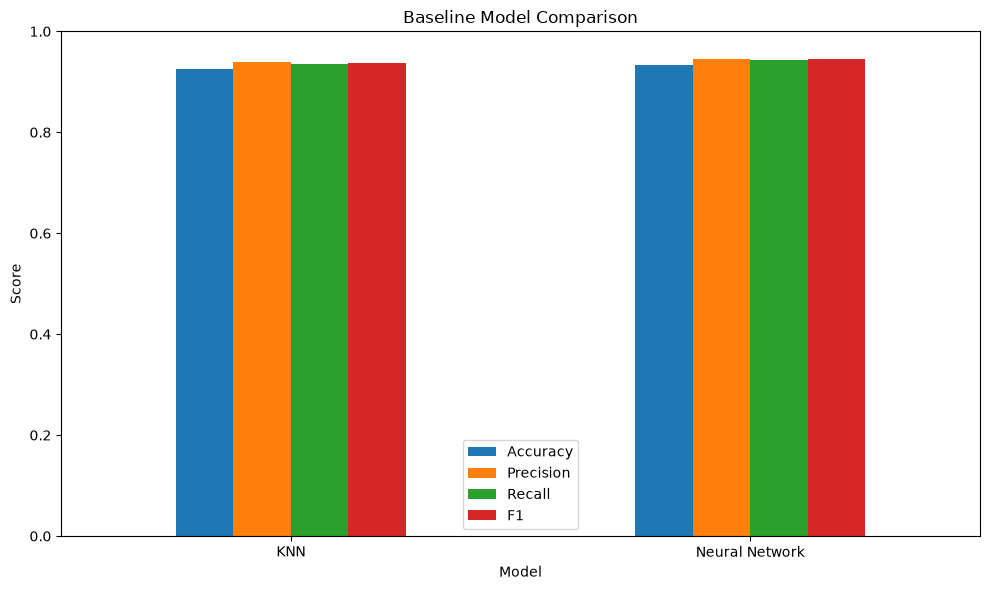

In [13]:
results_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

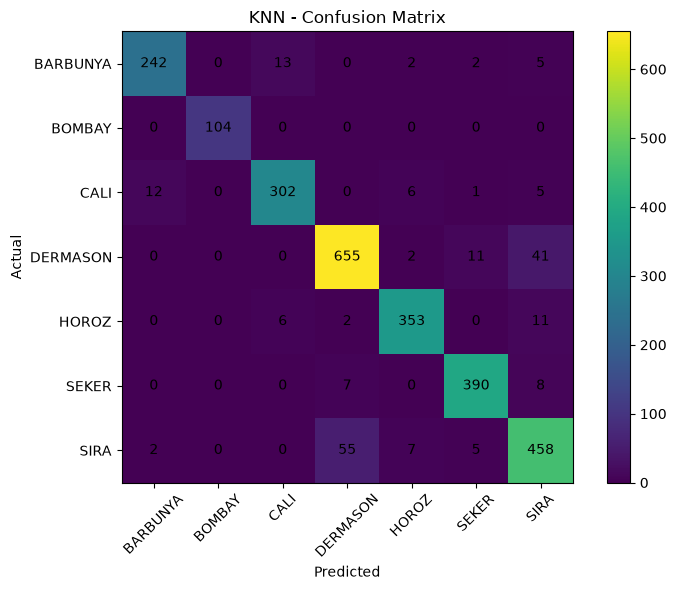

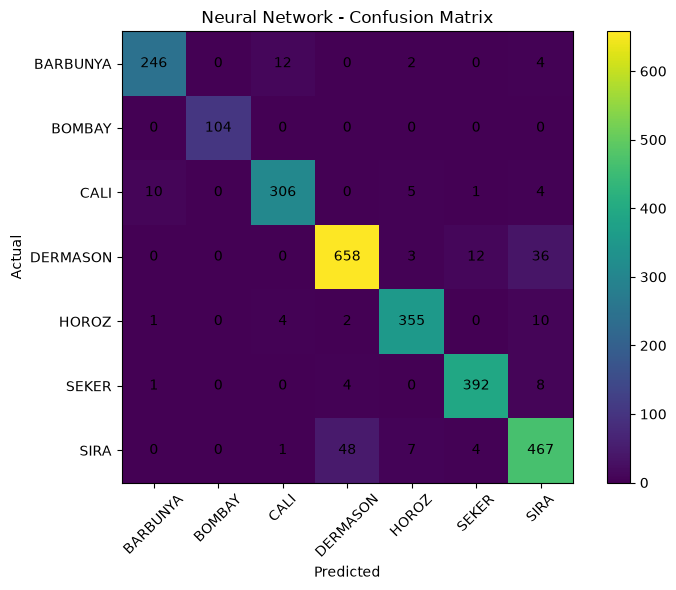

In [14]:
for model_name, cm in confusion_matrices.items():
    plt.figure(figsize=(8, 6))

    plt.imshow(cm)

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        range(len(classes)),
        classes,
        rotation=45
    )

    plt.yticks(
        range(len(classes)),
        classes
    )

    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

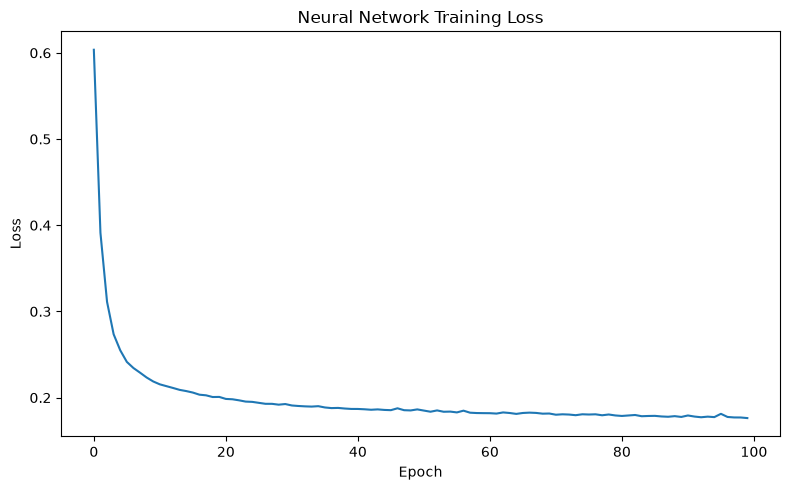

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(nn.history["loss"])

plt.title("Neural Network Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

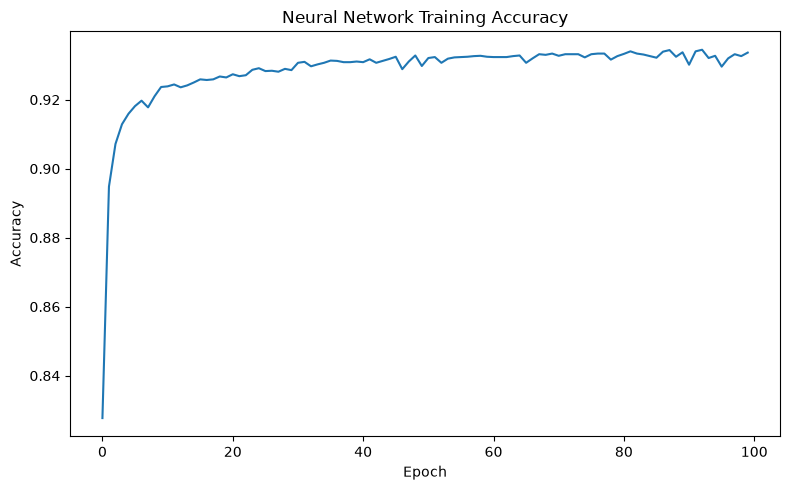

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(nn.history["accuracy"])

plt.title("Neural Network Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()